# Ocean surface variables — alternate spin-ups vs Full-CPL

Figures:
* `ocean_surface_mvars_Global_ts_yr0001-0350.pdf`

**Setup** holds everything you normally change: paths, the experiment table, labels, colors and years. Each analysis step then has a **settings** cell (its parameters and plot style) and a **compute & plot** cell that calls the shared classes in `../util/` directly. Figures are saved to `FIG_DIR` (public_html) and cached/derived data to `DATA_DIR` (public_html `data/`, indexed in `data/README.md`).

In [2]:
import os, sys
WF_ROOT = os.path.abspath("..")            # coupled_spinup_eval/
if WF_ROOT not in sys.path:
    sys.path.insert(0, WF_ROOT)
os.environ.setdefault("HDF5_USE_FILE_LOCKING", "FALSE")
%matplotlib inline

from dataclasses import dataclass
from typing import Optional, Tuple, List, Dict, Optional, Any
import os, re, glob
import numpy as np
import xarray as xr
import cftime
import json
import pandas as pd  
import math 
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats, signal
from matplotlib.ticker import (
    FixedLocator, FixedFormatter, AutoMinorLocator,
    MultipleLocator, NullFormatter
)
from matplotlib.lines import Line2D
from matplotlib.ticker import FormatStrFormatter

from util.alt_global_timeseries import FigureDataCollector, FigureExtractSpec, OCNDiagnosticsPlotter, PlotRequest
from util.experiments import build_exp_subdirs_from_run_dict, make_run_dict
from util.figures import publish

## Setup

In [3]:
# ---- paths ----
MODEL_ROOT   = "/lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/E3SMv3_testings"     # case directories
OUTPUT_ROOT  = "/lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/v3spinup_paper"   # published figures/ and data/
OUTPUT_URL   = "https://web.lcrc.anl.gov/public/e3sm/diagnostic_output/ac.szhang/v3spinup_paper"
FIG_DIR      = f"{OUTPUT_ROOT}/figures/ocn_sfc"
DATA_DIR     = f"{OUTPUT_ROOT}/data/ocn_sfc"               # cached/derived data (index: data/README.md)
OBS_DIR      = f"{OUTPUT_ROOT}/data/obs"                                          # HadSST Nino3.4 reference

# ---- experiments: case directory names (under MODEL_ROOT) and model-year periods ----
EXPERIMENTS = {
    "Full-CPL": {
        "spin-up":   {"name": "20231209.v3.LR.piControl-spinup.chrysalis",      "period": "0001-2000"},
        "piControl": {"name": "v3.LR.piControl",                                "period": "0001-0500"},
    },
    "AltBG1": {
        "spin-up":   {"name": "20240707.v3.LR.piControl.Rerun.GC2BC.chrysalis", "period": "0001-0220"},
        "piControl": {"name": "20240707.v3.LR.piControl.Rerun.GC2BC.chrysalis", "period": "0221-0350"},
    },
    "AltBG2": {
        "spin-up":   {"name": "20240818.v3.LR.piControl.Rerun.GC2BC.chrysalis", "period": "0001-0220"},
        "piControl": {"name": "20240818.v3.LR.piControl.Rerun.GC2BC.chrysalis", "period": "0221-0350"},
    },
    "AltBG3": {
        "spin-up":   {"name": "20241105.v3.LR.piControl.Rerun.BC2GC.anvil",     "period": "0001-2000"},
        "piControl": {"name": "20241105.v3.LR.piControl.Rerun.BC2GC.anvil",     "period": "0001-0500"},
    },
}
LABEL = {"Full-CPL": "FC", "AltBG1": "FC-FOSI-S1", "AltBG2": "FC-FOSI-S2", "AltBG3": "FC-FOSI-S3"}

# ---- analysis settings ----
EXPS        = ["Full-CPL", "AltBG1", "AltBG2"]   # experiments compared (plotting order)
COLORS      = ["black", "#cc0000", "#377eb8"]    # one per experiment
YEARS       = (1, 350)      # simulation years analysed (selects the MPAS-Analysis ts_0001-0350 run)
SWITCH_YEAR = 221           # vertical marker: first piControl year of the AltBG runs


In [4]:
# Shared inputs/outputs
run_dict = make_run_dict(EXPERIMENTS, MODEL_ROOT)
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(DATA_DIR, exist_ok=True)
publish(OUTPUT_ROOT, FIG_DIR)
print("figures ->", FIG_DIR)
print("data    ->", DATA_DIR)
print("web     ->", FIG_DIR.replace(OUTPUT_ROOT, OUTPUT_URL))

figures -> /lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/v3spinup_paper/figures/ocn_sfc
data    -> /lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/v3spinup_paper/data/ocn_sfc
web     -> https://web.lcrc.anl.gov/public/e3sm/diagnostic_output/ac.szhang/v3spinup_paper/figures/ocn_sfc


## 1 Surface ocean time series
### Settings

In [5]:
# === Paths ===
data_dir    = MODEL_ROOT
out_dir     = DATA_DIR
fig_dir     = FIG_DIR  # or os.path.join(results_dir, "figures")
os.makedirs(out_dir, exist_ok=True)
os.makedirs(fig_dir, exist_ok=True)

# === Experiments ===
exp_type = "spin-up"
exp_tags = EXPS
labels   = [LABEL[t] for t in EXPS]  # for plotting later
colors   = list(COLORS)

# shading windows (years) for each experiment tag
exp_shas = {
    "Full-CPL": None,
    "AltBG1": {
        "segments": [(11, 20), (81, 90), (151, 160)],
        "alpha": 0.4,
        "hatch": "///",
        "color": colors[EXPS.index("AltBG1")],   # hatch in the experiment's line color
    },
    "AltBG2": {
        "segments": [(11, 50)],
        "alpha": 0.4,
        "hatch": "..",
        "color": colors[EXPS.index("AltBG2")],   # hatch in the experiment's line color
    },
}

# === Time window ===
time_unit = "0001-01-01 00:00:00"   # origin for constructing time if absent
calendar  = "noleap"
ts_window = YEARS                # simulation years
year_min, year_max = ts_window
year_token = f"{year_min:04d}-{year_max:04d}"

# (Optional) plotting padding you used before; keep if needed later
year_min_plot, year_max_plot = year_min - 1, year_max + 1

annual_mean = False
annual_weighted = False

# === flux time-series base ===
flux_vars = ["Fmass", "Mass_net"]
flux_vbrs = ["Mass_net"] # base vars in nc file 
flux_per_area_vars = ["Fmass"]
flux_ts_base = "post/time_series/ocn"
flux_clim_len = 50 
flux_coef = 86400.0 * 365.0

# === mpas-analysis base ===
mpas_vars = ["SST","SSS","SSH","iceVolumeNH","iceVolumeSH","iceAreaNH","iceAreaSH"]
mpas_ts_base = "post/analysis/mpas_analysis"
mpas_clim_len = 50

# Choose region key used by your registry ("Global", "Nino3.4", etc.)
region_key = "Global"
# region selection metadata (matches your previous choices)
reg_dim = "nOceanRegions"
reg_var = None  # regionNames var (None means "don't try to decode names")
engine = "netcdf4"
chunks = None
use_mfdataset = True
verbose = True 

# now collect the data to plot 
collect_figure_data = True 
out_base = f"ocean_surface_mvars_{region_key}_ts_yr{year_min:04d}-{year_max:04d}"
out_ncb = os.path.join(out_dir, f"{out_base}")
out_pdf = os.path.join(fig_dir, f"{out_base}.pdf")

plot_info = {
    "SST": dict(
        short="SST", unit=r"$\circ$C",
        label="(a) Sea surface temperature (Global)",
        ylim=(17.0,18.7), scale=1.0
    ),
    "SSS": dict(
        short="SSS", unit="PSU",
        label="(b) Sea surface salinity (Global)",
        ylim=(34.6,34.9), scale=1.0
    ),
    "Fmass": dict(
        short=r"$\overline{M}_{net}$",
        unit="mm yr$^{-1}$",
        label=r"(c) Net Mass Fluxes ($\overline{M}_{net}$, Global)",
        ylim=(-20,30), scale=1.0,   # ⭐ conversion happens here
    ),
    "SSH": dict(
        short="SSH", unit="cm",
        label="(d) Sea surface height (Global)",
        ylim=(-8,10), scale=1.0
    ),
    "iceVolumeNH": dict(
        short="IceVol NH", unit=r"$\times$10$^{3}$ m$^3$",
        label="(e) Sea-ice volume (NH)",
        ylim=(10,35), scale=1.0
    ),
    "iceVolumeSH": dict(
        short="IceVol SH", unit=r"$\times$10$^{3}$ m$^3$",
        label="(f) Sea-ice volume (SH)",
        ylim=(5,30), scale=1.0
    ),
    "iceAreaNH": dict(
        short="IceArea NH", unit=r"$\times$10$^{6}$ m$^2$",
        label="(g) Sea-ice area (NH)",
        ylim=(9,13), scale=1.0
    ),
    "iceAreaSH": dict(
        short="IceArea SH", unit=r"$\times$10$^{6}$ m$^2$",
        label="(h) Sea-ice area (SH)",
        ylim=(6,16), scale=1.0
    ),
}


### Compute & plot


[Extracted series summary]
  Full-CPL:
    SST           n=  4200  min=17.07  max=18.69
    SSS           n=  4200  min=34.69  max=34.8
    SSH           n=  4200  min=-1.514  max=7.422
    iceVolumeNH   n=  4200  min=5.724  max=40.25
    iceVolumeSH   n=  4200  min=3.659  max=33.24
    iceAreaNH     n=  4200  min=3.406  max=18.58
    iceAreaSH     n=  4200  min=1.744  max=21.74
  AltBG1:
    SST           n=  4200  min=17.11  max=18.69
    SSS           n=  4200  min=34.68  max=34.8
    SSH           n=  4200  min=-2.148  max=8.521
    iceVolumeNH   n=  4200  min=6.67  max=40.25
    iceVolumeSH   n=  4200  min=2.804  max=33.16
    iceAreaNH     n=  4200  min=4.014  max=17.82
    iceAreaSH     n=  4200  min=1.333  max=21.74
  AltBG2:
    SST           n=  4200  min=17.18  max=18.69
    SSS           n=  4200  min=34.69  max=34.8
    SSH           n=  4200  min=-5.493  max=6.958
    iceVolumeNH   n=  4200  min=5.493  max=40.25
    iceVolumeSH   n=  4200  min=3.627  max=33.16
    iceAre

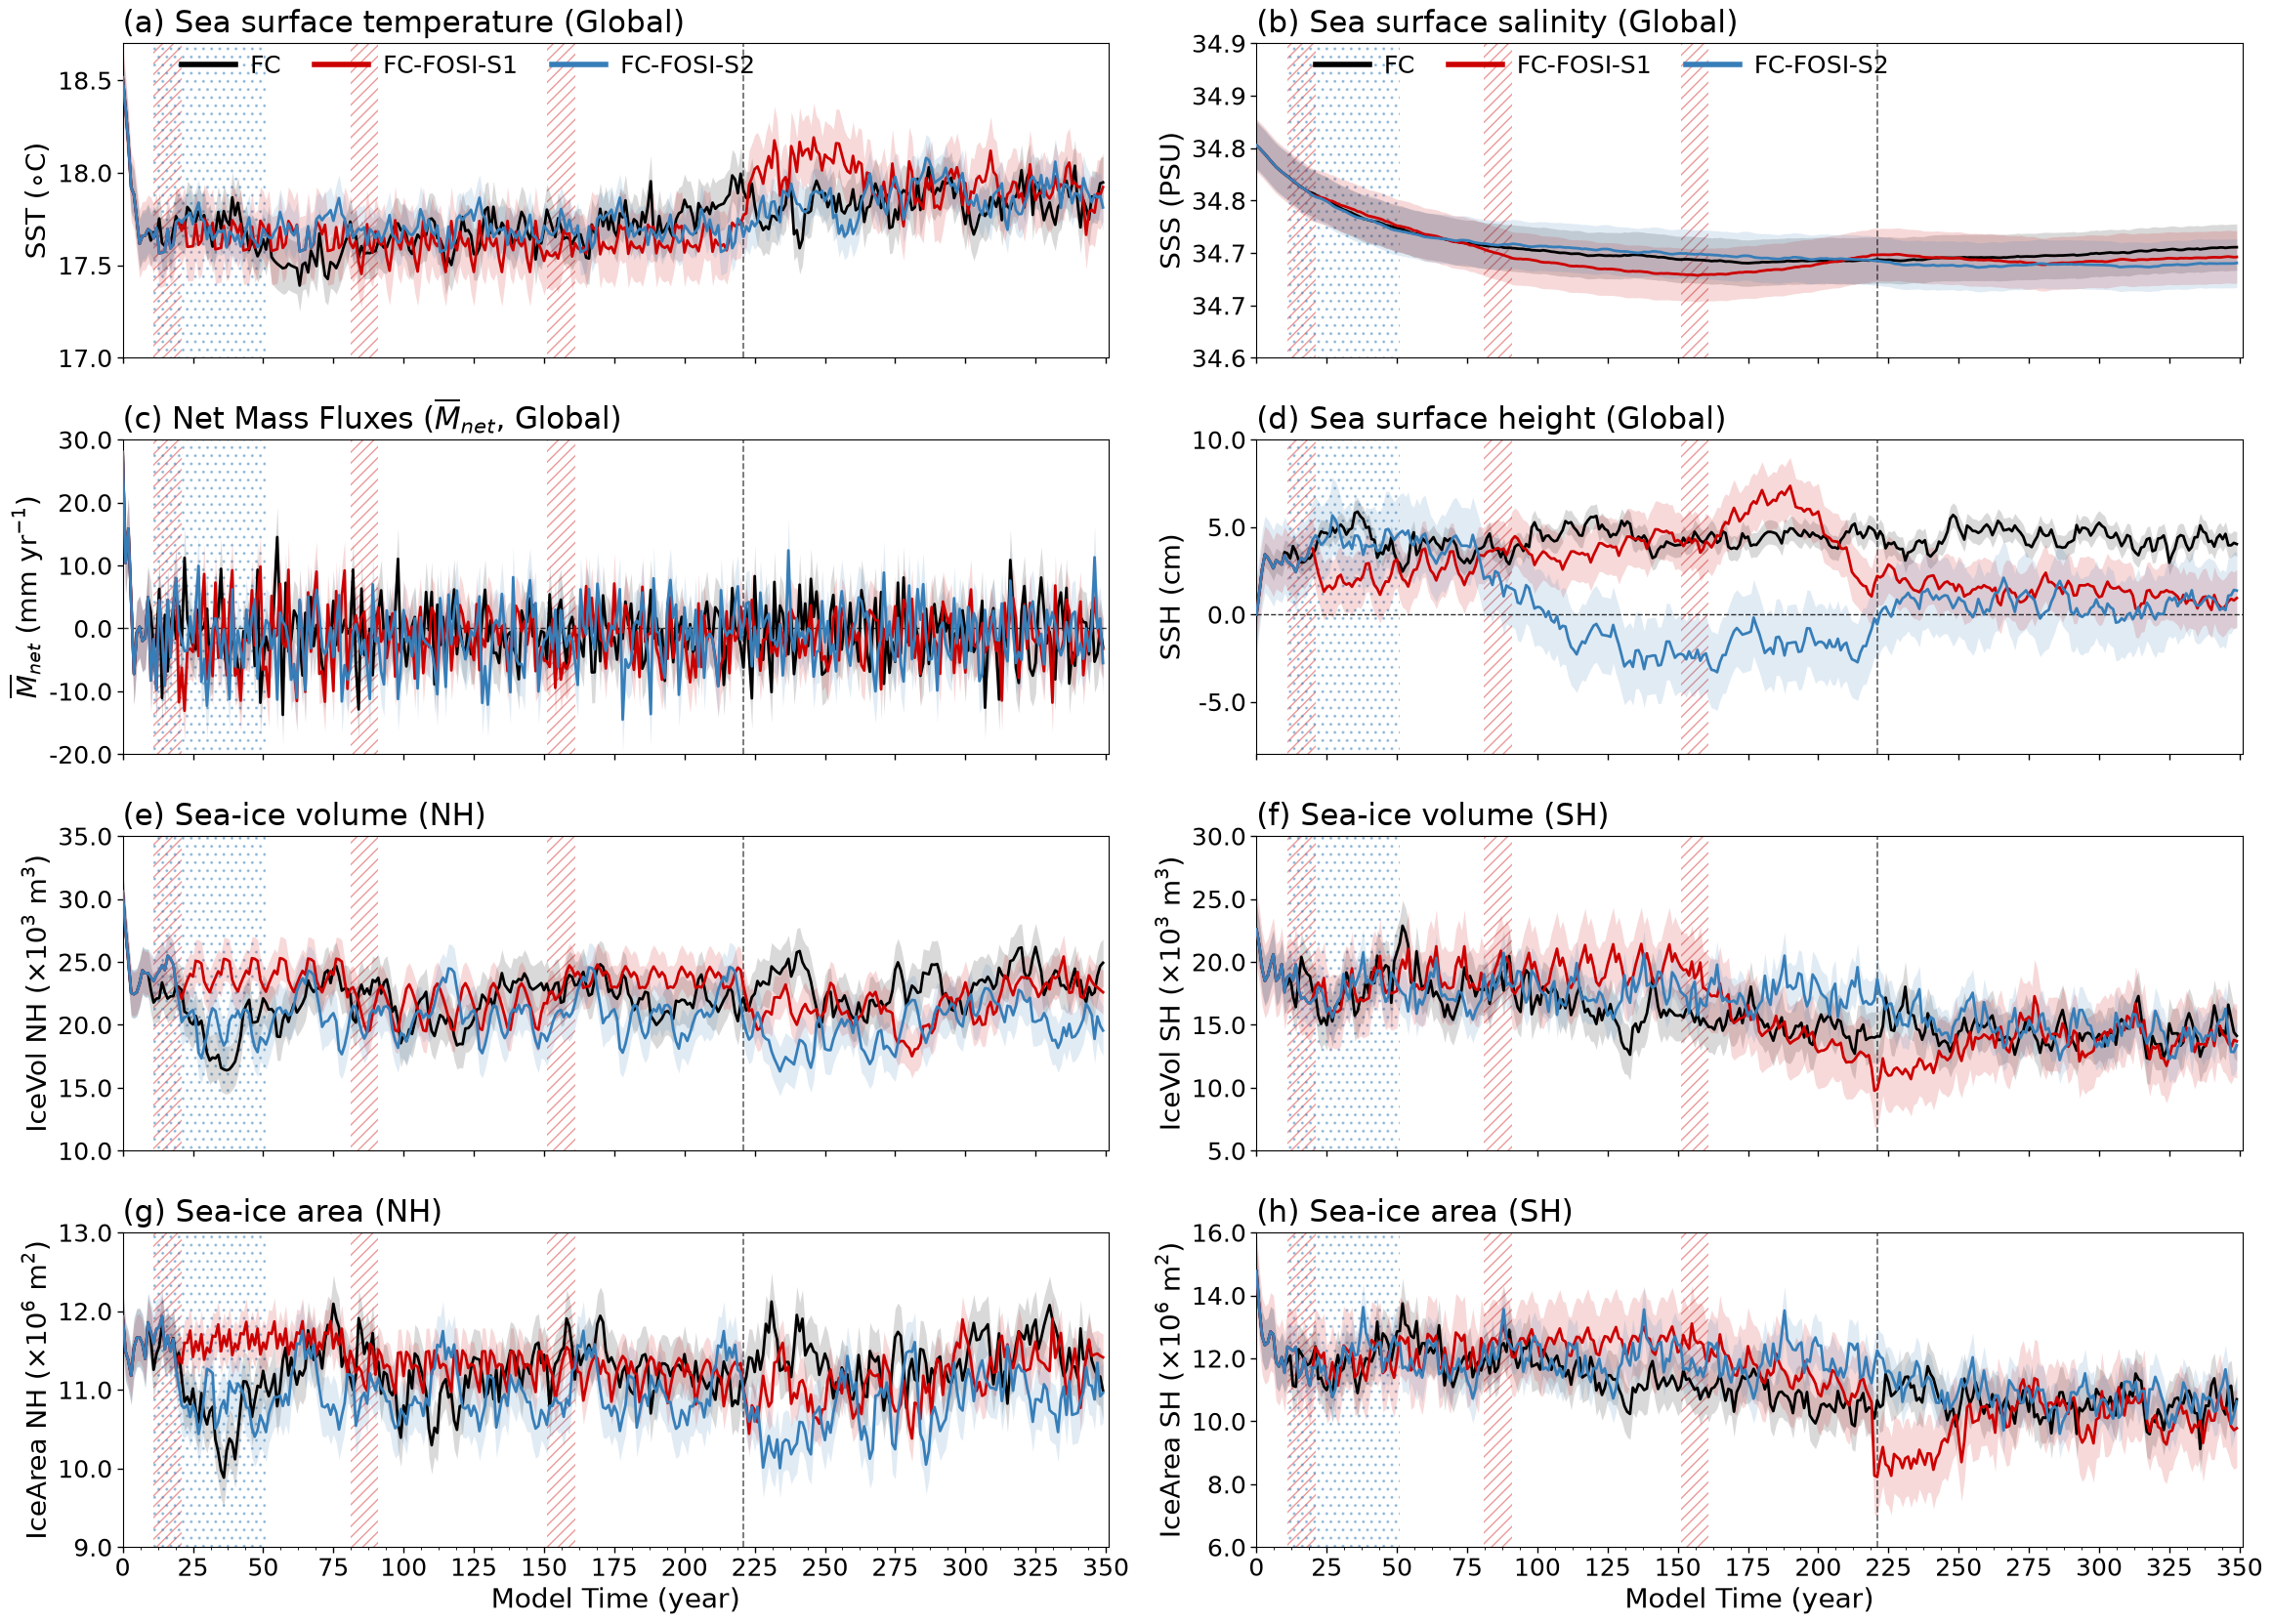

Saved: /lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/v3spinup_paper/figures/ocn_sfc/ocean_surface_mvars_Global_ts_yr0001-0350.pdf
web: https://web.lcrc.anl.gov/public/e3sm/diagnostic_output/ac.szhang/v3spinup_paper/figures/ocn_sfc


In [6]:
# collect or process figure data 
collector = FigureDataCollector(
    run_dict=run_dict,
    exp_tags=exp_tags,
    exp_type=exp_type,
    ts_window=ts_window,
    data_dir=data_dir,
    year_token=year_token,
    time_unit=time_unit,
    calendar=calendar,
    region_key=region_key,
    reg_dim=reg_dim,
    reg_var=reg_var,
    engine=engine,
    chunks=chunks,
    use_mfdataset=use_mfdataset,
    verbose=verbose,
)

if collect_figure_data: 
    spec = FigureExtractSpec(
        ocn_ts_base=mpas_ts_base,
        ocn_climo_len=mpas_clim_len,
        ocn_need_base=mpas_vars,
        flux_ts_base=flux_ts_base,
        flux_climo_len=flux_clim_len,
        flux_need_vars=flux_vars,
        flux_need_base=flux_vbrs,
        flux_annual_mean=annual_mean,
        flux_annual_weighted=annual_weighted,
        flux_coef_flx=flux_coef,
        flux_per_area_vars=flux_per_area_vars,
    )

    plot_data = collector.collect(
        spec=spec,
        plot_vars=list(plot_info.keys()),
    )

    # ---------------------------------------
    # Save TS data (the exact plotted series) 
    # ---------------------------------------
    collector.save_per_exp(
        out_nc_base=out_ncb,
        plot_data=plot_data,
        plot_info=plot_info,
        freq="annual" if annual_mean else "monthly",
        year_min_for_coords=year_min_plot,   # or year_min, whichever your plotter uses
        year_max_for_meta=year_max_plot,
        apply_scale=True,                    # saves exactly what you plot
        attrs={
            "region": region_key,
            "calendar": calendar,
            "ts_window_years": f"{year_min}-{year_max}",
            "figure_pdf": os.path.basename(out_pdf),
        },
    )
else:
    plot_data = collector.load_per_exp(
        out_nc_base=out_ncb, 
        ts_var_keys=list(plot_info.keys())
    )

print(plot_data.keys())

# ------------------------------------------------------------------
# At this point you have:
#   data[exp]["SST"], data[exp]["SSS"], data[exp]["SSH"],
#   data[exp]["iceAreaNH"], ... etc.
# and you can pass these series into your plotter next.
# ------------------------------------------------------------------
exp_order  = exp_tags          # <-- use tags directly
exp_labels = labels

annual_mean = True          # convert monthly -> annual for plotting
compute_anomaly = False
running_mean = False
running_mean_months = 12
use_filter = False
trend_years = 100
trend_unit = "per_decade"

# --- make ONE figure, 2 columns ---
var_list = list(plot_info.keys())
nvars = len(var_list)
ncols = 2
nrows = int(math.ceil(nvars / ncols))
figsize = (28, 20)
fontsize = 22
step_yrs = 25
ref_yrs = [SWITCH_YEAR]
std_band   = True
std_center = "filtered"
std_source = "raw"
std_mode   = "global"
show_title = True          # 
use_panel_labels = False    # set False if you already hard-coded (a)(b)... in plot_info["label"]
sha_alpha = 0.03
stats_format = "json"          
constrained_layout = False
wspace = 0.15  # column space
hspace = 0.26  # row space

plotter = OCNDiagnosticsPlotter(
    year_min=year_min_plot,
    year_max=year_max_plot,
    annual_mean=annual_mean,          # convert monthly -> annual for plotting
    compute_anomaly=compute_anomaly,
    running_mean=running_mean,
    running_mean_months=running_mean_months,
    use_filter=use_filter,
    trend_years=trend_years,
    trend_unit=trend_unit,
)

# do plot 
fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=figsize,
    constrained_layout=constrained_layout,
)

fig.subplots_adjust(
    wspace=wspace,  # column space
    hspace=hspace   # row space
)

axes = np.atleast_2d(axes)

for i, var_key in enumerate(var_list):
    r = i // ncols
    c = i % ncols
    ax = axes[r, c]

    vinfo = plot_info[var_key]

    # bottom-most occupied panel in each column
    is_last_row = (r == nrows - 1)
    is_last_var_in_column = (i + ncols >= nvars)
    show_xticks = is_last_row or is_last_var_in_column
    show_ylabel = True #(c == 0)
    panel_label = f"({chr(ord('a') + i)})" if use_panel_labels else ""
    # legend only on the top row panels (both columns)
    legend_pos = "upper left" if (r == 0) else None

    req = PlotRequest(
        key=var_key,
        vname=vinfo["short"],
        vunit=vinfo["unit"],
        scale=vinfo.get("scale", 1.0),
        ylim=vinfo.get("ylim", None),
        # title text you want in each panel
        title=vinfo["label"],
        y_label=fr"{vinfo['short']} ({vinfo['unit']})",
        # multipanel controls
        panel_label=panel_label,
        show_xlabel=show_xticks,   # only bottom-of-column panels get xlabel
        show_xticks=show_xticks,   # only bottom-of-column panels get tick labels
        show_ylabel=show_ylabel,
        show_title=show_title,
        legend_loc=legend_pos,     # disable per-axis legend
    )

    stats = plotter.plot_on_axis(
        ax=ax,
        data=plot_data,
        var_key=var_key,
        exp_order=exp_order,
        exp_labels=exp_labels,
        colors=colors,
        req=req,
        fontsize=fontsize,
        step_yrs=step_yrs,
        ref_yrs=ref_yrs,
        std_band=std_band,
        std_center=std_center,
        std_source=std_source,
        std_mode=std_mode,
        exp_shas=exp_shas,
        sha_alpha=sha_alpha,
        save_stats_base=out_ncb,      
        stats_format=stats_format,          
    )
# turn off unused panels if odd number of variables
for j in range(nvars, nrows * ncols):
    rr = j // ncols
    cc = j % ncols
    axes[rr, cc].axis("off")

fig.savefig(out_pdf, dpi=600, bbox_inches="tight")
plt.show()
plt.close(fig)
print("Saved:", out_pdf)

publish(FIG_DIR, DATA_DIR)
print("web:", FIG_DIR.replace(OUTPUT_ROOT, OUTPUT_URL))
